In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading Module

df = pd.read_csv('crop_yield[MissingValues&Duplicates].csv')
display(df.head())

,State_Name,Season,N,P,K,rainfall,humidity,temperature,Crop Yield (kg per hectare),Rainfall_Temperature,...,Soil_Type,Irrigation_Method,Fertilizer_Used_kg,Pesticide_Usage_kg,Soil_Moisture,Sunshine_hours,Wind_speed,Altitude_m,Organic_Carbon,Soil_Texture
0,Kerala,Whole Year,41.0,92.0,54.0,2917.102941,66.83,32.60,3324.563123,95097.55588,...,Neutral,Rainfed,170.78,9.58,50.96,4.25,9.55,409.74,0.38,Clay
1,West Bengal,Whole Year,35.0,9.0,83.0,852.525083,48.47,25.67,5471.575701,21884.31889,...,Neutral,Sprinkler,91.18,11.47,35.98,7.19,15.93,310.58,0.63,Clay
2,Assam,Whole Year,42.0,6.0,23.0,1152.740698,76.53,17.61,1734.917776,20299.76369,...,Neutral,Drip,172.09,13.42,48.97,5.79,8.85,10.00,0.86,Sandy
3,Meghalaya,Whole Year,116.0,37.0,136.0,1228.057333,32.12,36.37,4438.622051,44664.44520,...,Neutral,Rainfed,98.29,8.71,25.21,7.06,5.69,412.56,0.54,Loamy
4,Meghalaya,Whole Year,116.0,37.0,136.0,1228.057333,32.12,36.37,4438.622051,44664.44520,...,Neutral,Rainfed,98.29,8.71,25.21,7.06,5.69,412.56,0.54,Loamy


In [2]:
## Data Exploration Module

print(f"Shape of the DataFrame: {df.shape}")
print("\nColumns in the DataFrame:")
for col in df.columns:
    print(f"- {col}")
print("\nData types of each column:")
df.info()

print("\nSummary statistics of the DataFrame:")
df.describe()

Shape of the DataFrame: (102682, 25)

Columns in the DataFrame:
- State_Name
- Season
- N
- P
- K
- rainfall
- humidity
- temperature
- Crop Yield (kg per hectare)
- Rainfall_Temperature
- Humidity_Temperature
- NPK_Ratio
- Weather_Index
- Crop
- pH
- Soil_Type
- Irrigation_Method
- Fertilizer_Used_kg
- Pesticide_Usage_kg
- Soil_Moisture
- Sunshine_hours
- Wind_speed
- Altitude_m
- Organic_Carbon
- Soil_Texture

Data types of each column:
<class 'pandas.DataFrame'>
RangeIndex: 102682 entries, 0 to 102681
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   State_Name                   102681 non-null  str    
 1   Season                       102676 non-null  str    
 2   N                            102671 non-null  float64
 3   P                            102669 non-null  float64
 4   K                            102662 non-null  float64
 5   rainfall                     102658 non

,N,P,K,rainfall,humidity,temperature,Crop Yield (kg per hectare),Rainfall_Temperature,Humidity_Temperature,NPK_Ratio,Weather_Index,pH,Fertilizer_Used_kg,Pesticide_Usage_kg,Soil_Moisture,Sunshine_hours,Wind_speed,Altitude_m,Organic_Carbon
count,102671.000000,102669.000000,102662.000000,102658.000000,102654.000000,102655.000000,102651.000000,102667.000000,102659.000000,102657.000000,102656.000000,102667.000000,102666.000000,102663.000000,102669.000000,102672.000000,102676.000000,102678.000000,102682.000000
mean,71.059666,51.502459,76.304962,1682.223256,59.634833,27.555046,3448.349664,46430.662920,1644.991142,66.289884,1.340873,6.463657,120.048263,8.002646,40.787396,6.998140,10.026105,354.206536,0.802556
std,39.697976,26.535849,41.480209,789.630546,17.049414,7.175162,1497.764516,25720.622890,662.903377,21.586410,1.063525,0.603935,39.732539,2.985769,10.640909,1.499353,3.921577,192.166961,0.294353
min,0.000000,5.000000,5.000000,400.085492,30.000000,15.010000,800.123554,6170.123069,463.809000,4.333333,0.177714,4.500000,20.000000,0.000000,14.060000,3.000000,2.000000,10.000000,0.200000
25%,38.000000,28.000000,42.000000,987.104370,44.520000,21.820000,2138.634719,25250.211190,1144.086100,51.666667,0.610164,5.960000,93.120000,5.970000,31.950000,5.980000,7.290000,215.770000,0.600000
50%,68.000000,53.000000,78.000000,1683.347473,59.140000,27.350000,3488.298119,42366.594080,1503.376600,66.333333,0.947065,6.460000,120.050000,8.000000,40.580000,6.990000,10.010000,350.520000,0.800000
75%,107.000000,74.000000,112.000000,2426.116024,73.820000,33.900000,4703.621019,63913.071080,2056.238800,81.000000,1.679415,6.970000,146.880000,10.020000,49.470000,8.010000,12.680000,484.635000,1.000000
max,139.000000,99.000000,149.000000,2999.630524,90.000000,40.000000,5999.323801,119249.622200,3575.536900,127.666667,8.334535,8.000000,283.110000,21.750000,69.160000,12.000000,25.000000,1274.270000,2.030000


In [3]:
## Cleaning Module

print("Missing values per column in the DataFrame:")
print(df.isnull().sum())

totalmv = df.isnull().sum().sum()
print(f"\nTotal number of missing values: {totalmv}")

df_cleaned = df.dropna()

rows_before = len(df)
rows_after = len(df_cleaned)
rows_dropped = rows_before - rows_after

print(f"Number of rows dropped: {rows_dropped}")

duplicate_rows = df_cleaned.duplicated().sum()
print(f"\nTotal number of duplicate rows found: {duplicate_rows}")

df_no_duplicates = df.drop_duplicates()

rows_before_dup_drop = len(df)
rows_after_dup_drop = len(df_no_duplicates)
rows_duplicates_dropped = rows_before_dup_drop - rows_after_dup_drop

print(f"Number of duplicate rows dropped: {rows_duplicates_dropped}")

output_filename = 'crop_yield[Cleaned].csv'
df_no_duplicates.to_csv(output_filename, index=False)
print(f"\nDataFrame without duplicates saved to {output_filename}")


Missing values per column in the DataFrame:
State_Name                      1
Season                          6
N                              11
P                              13
K                              20
rainfall                       24
humidity                       28
temperature                    27
Crop Yield (kg per hectare)    31
Rainfall_Temperature           15
Humidity_Temperature           23
NPK_Ratio                      25
Weather_Index                  26
Crop                           19
pH                             15
Soil_Type                      21
Irrigation_Method              32
Fertilizer_Used_kg             16
Pesticide_Usage_kg             19
Soil_Moisture                  13
Sunshine_hours                 10
Wind_speed                      6
Altitude_m                      4
Organic_Carbon                  0
Soil_Texture                    0
dtype: int64

Total number of missing values: 405
Number of rows dropped: 127

Total number of duplicate r


Numeric columns (19): ['N', 'P', 'K', 'rainfall', 'humidity', 'temperature', 'Crop Yield (kg per hectare)', 'Rainfall_Temperature', 'Humidity_Temperature', 'NPK_Ratio', 'Weather_Index', 'pH', 'Fertilizer_Used_kg', 'Pesticide_Usage_kg', 'Soil_Moisture', 'Sunshine_hours', 'Wind_speed', 'Altitude_m', 'Organic_Carbon']
String columns (6): ['State_Name', 'Season', 'Crop', 'Soil_Type', 'Irrigation_Method', 'Soil_Texture']
Analyzing 19 numeric columns: ['N', 'P', 'K', 'rainfall', 'humidity']...

Outliers per column (IQR):
Weather_Index                  7146
Altitude_m                      392
Pesticide_Usage_kg              384
Organic_Carbon                  373
Wind_speed                      373
Fertilizer_Used_kg              350
Sunshine_hours                  342
Humidity_Temperature            248
NPK_Ratio                        61
N                                 0
P                                 0
K                                 0
Rainfall_Temperature              0
temperatur

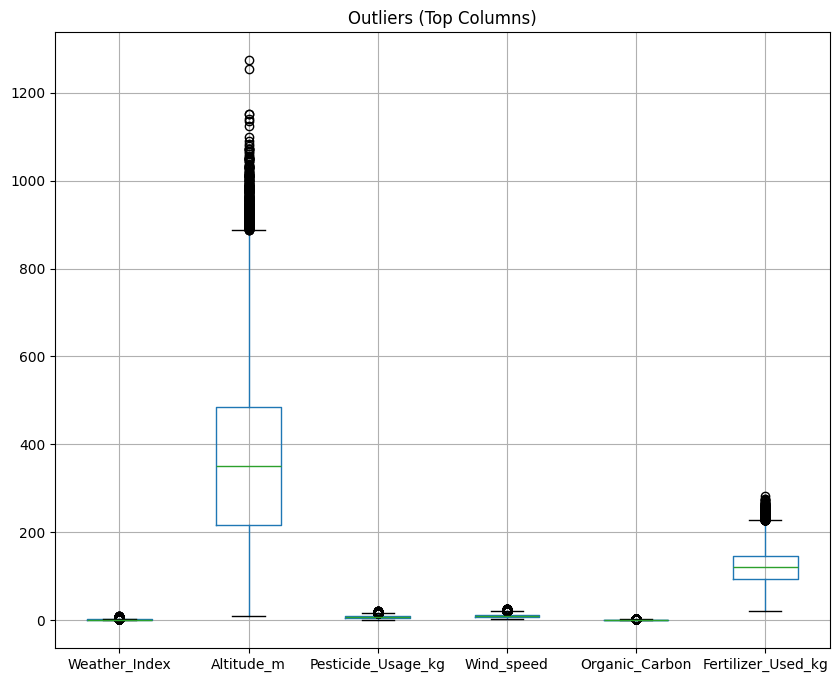


 New Shape: (102675, 25) → (93316, 25)
Rows kept: 93316 (90.9%)


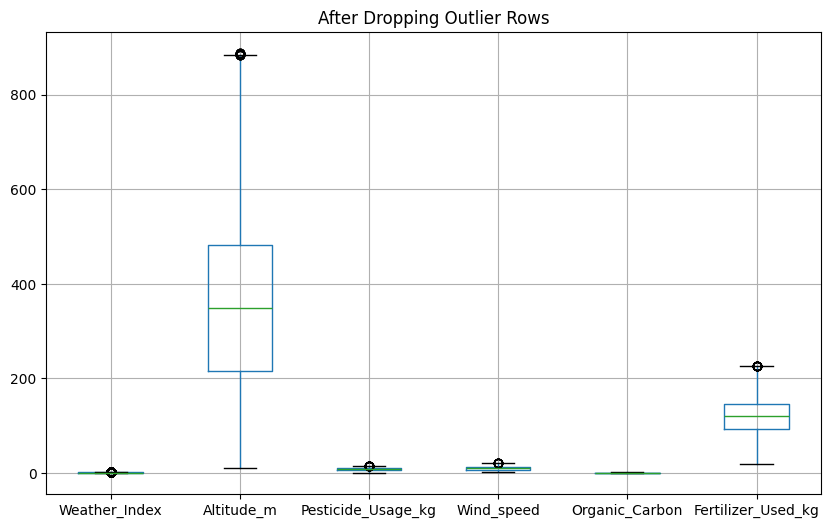

In [6]:
## Outliers Detection & Handling Module

df = pd.read_csv('crop_yield[Cleaned].csv')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
string_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"String columns ({len(string_cols)}): {string_cols}")


print(f"Analyzing {len(numeric_cols)} numeric columns: {numeric_cols[:5]}...\n")

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_per_col = ((df[numeric_cols] < lower) | (df[numeric_cols] > upper)).sum()
print("Outliers per column (IQR):")
print(outliers_per_col.sort_values(ascending=False))

total_outliers = outliers_per_col.sum()
print(f"\nTotal outliers: {total_outliers} ({total_outliers/len(df)*100:.1f}% rows affected)")

plt.figure(figsize=(10,8))
top_cols = outliers_per_col.nlargest(6).index
df[top_cols].boxplot()
plt.title('Outliers (Top Columns)')
plt.show()

# compute boolean mask per row (any numeric column is an outlier)
outlier_mask = ((df[numeric_cols] < lower) | (df[numeric_cols] > upper)).any(axis=1)
# use .loc to avoid reindexing warnings and ensure index alignment
df_no_outliers = df.loc[~outlier_mask].copy()

print(f"\n New Shape: {df.shape} → {df_no_outliers.shape}")
print(f"Rows kept: {len(df_no_outliers)} ({100*len(df_no_outliers)/len(df):.1f}%)")

plt.figure(figsize=(10,6))
top_cols = outliers_per_col.nlargest(6).index  # From your code
df_no_outliers[top_cols].boxplot()
plt.title('After Dropping Outlier Rows')
plt.show()

# Updated df
df = df_no_outliers

Crop Yield Stats:
count    93288.00
mean      3452.41
std       1489.04
min        800.12
25%       2150.09
50%       3526.96
75%       4684.02
max       5999.32
Name: Crop Yield (kg per hectare), dtype: float64


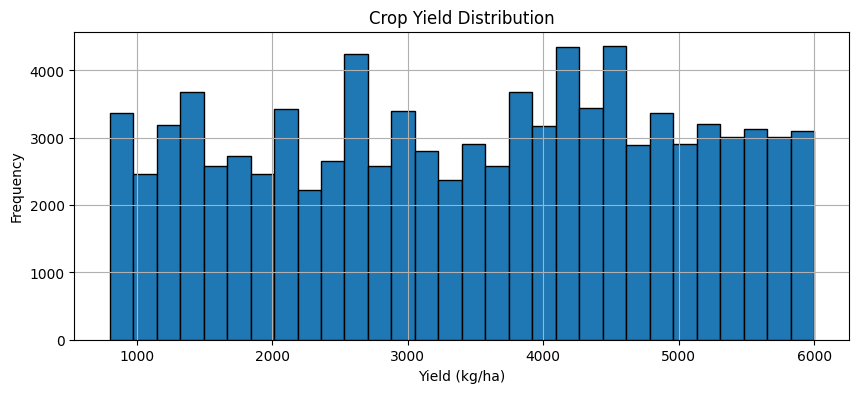

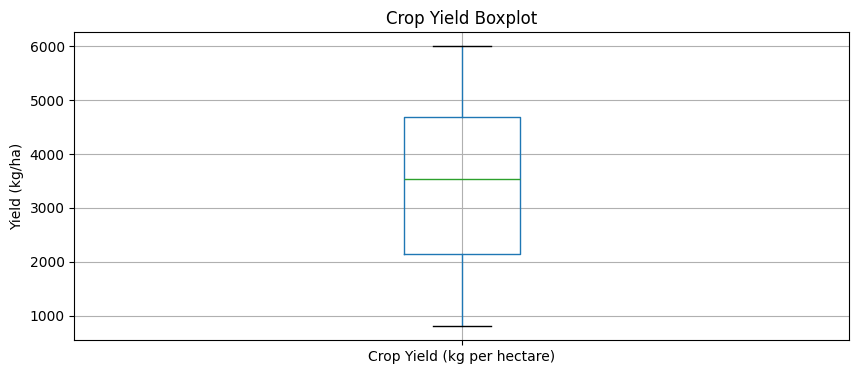

In [7]:
## Univariate Analysis Module

yield_col = 'Crop Yield (kg per hectare)'

print("Crop Yield Stats:")
print(df[yield_col].describe().round(2))

# Histogram
plt.figure(figsize=(10, 4))
df[yield_col].hist(bins=30, edgecolor='black')
plt.title('Crop Yield Distribution')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
plt.show()

# Boxplot
plt.figure(figsize=(10, 4))
df.boxplot(column=yield_col)
plt.title('Crop Yield Boxplot')
plt.ylabel('Yield (kg/ha)')
plt.show()

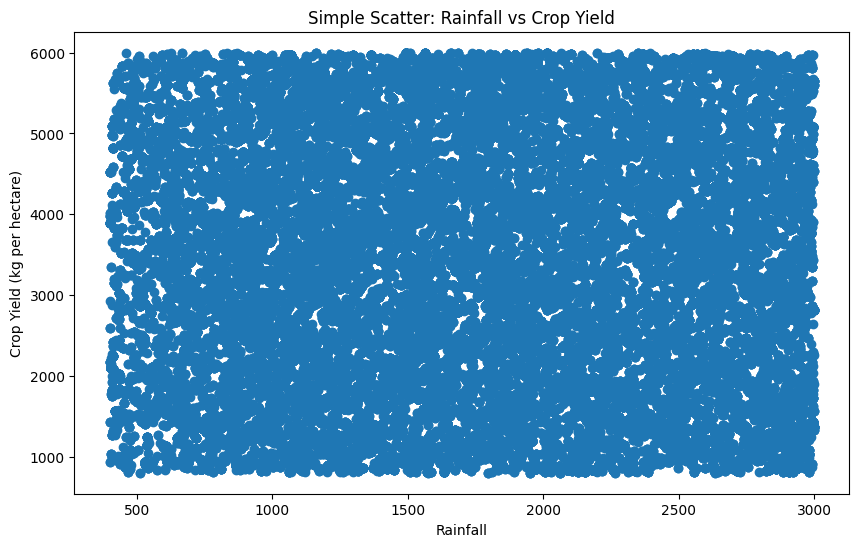

In [8]:
## Bivariate Analysis Module

plt.figure(figsize=(10, 6))
plt.scatter(df['rainfall'], df['Crop Yield (kg per hectare)'])
plt.xlabel('Rainfall')
plt.ylabel('Crop Yield (kg per hectare)')
plt.title('Simple Scatter: Rainfall vs Crop Yield')
plt.show()


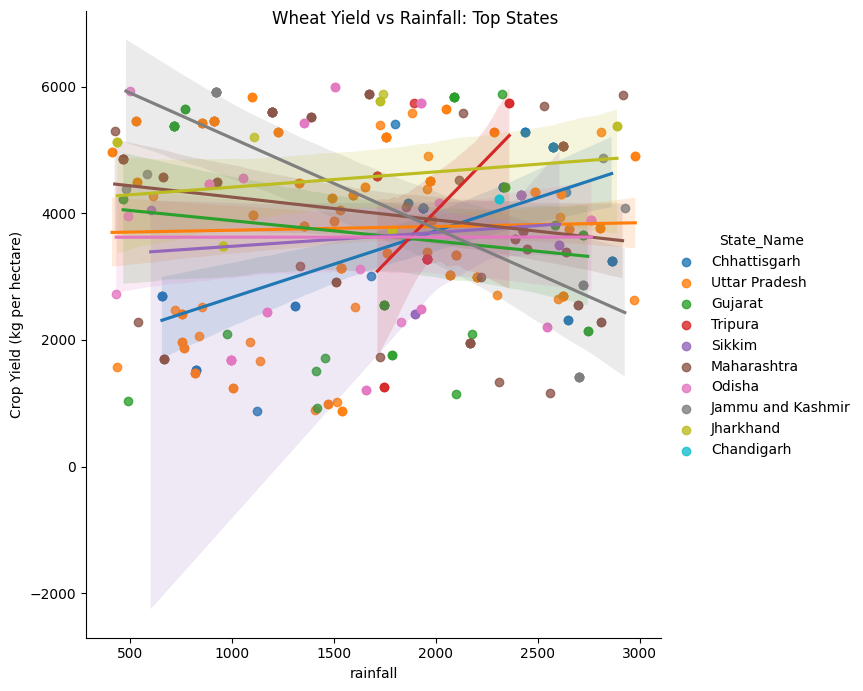

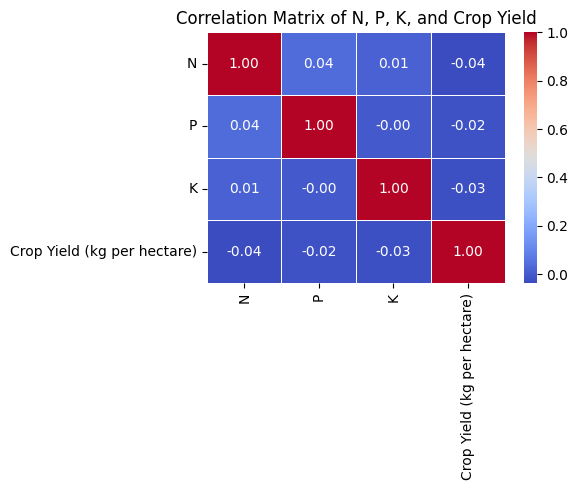

In [9]:
## Multivariate Analysis Module - Scatter Plot

df_wheat = df[df['Crop'] == 'Wheat']
top_states = df_wheat.groupby('State_Name')['Crop Yield (kg per hectare)'].mean().nlargest(10).index
df_top = df_wheat[df_wheat['State_Name'].isin(top_states)]
sns.lmplot(data=df_top, x='rainfall', y='Crop Yield (kg per hectare)', hue='State_Name', height=7)
plt.suptitle('Wheat Yield vs Rainfall: Top States')

## Correlation Matrix
key_features = ['N', 'P', 'K', 'Crop Yield (kg per hectare)']
focused_df = df[key_features]
correlation_matrix_focused = focused_df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_focused, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of N, P, K, and Crop Yield')
plt.tight_layout()
plt.show()


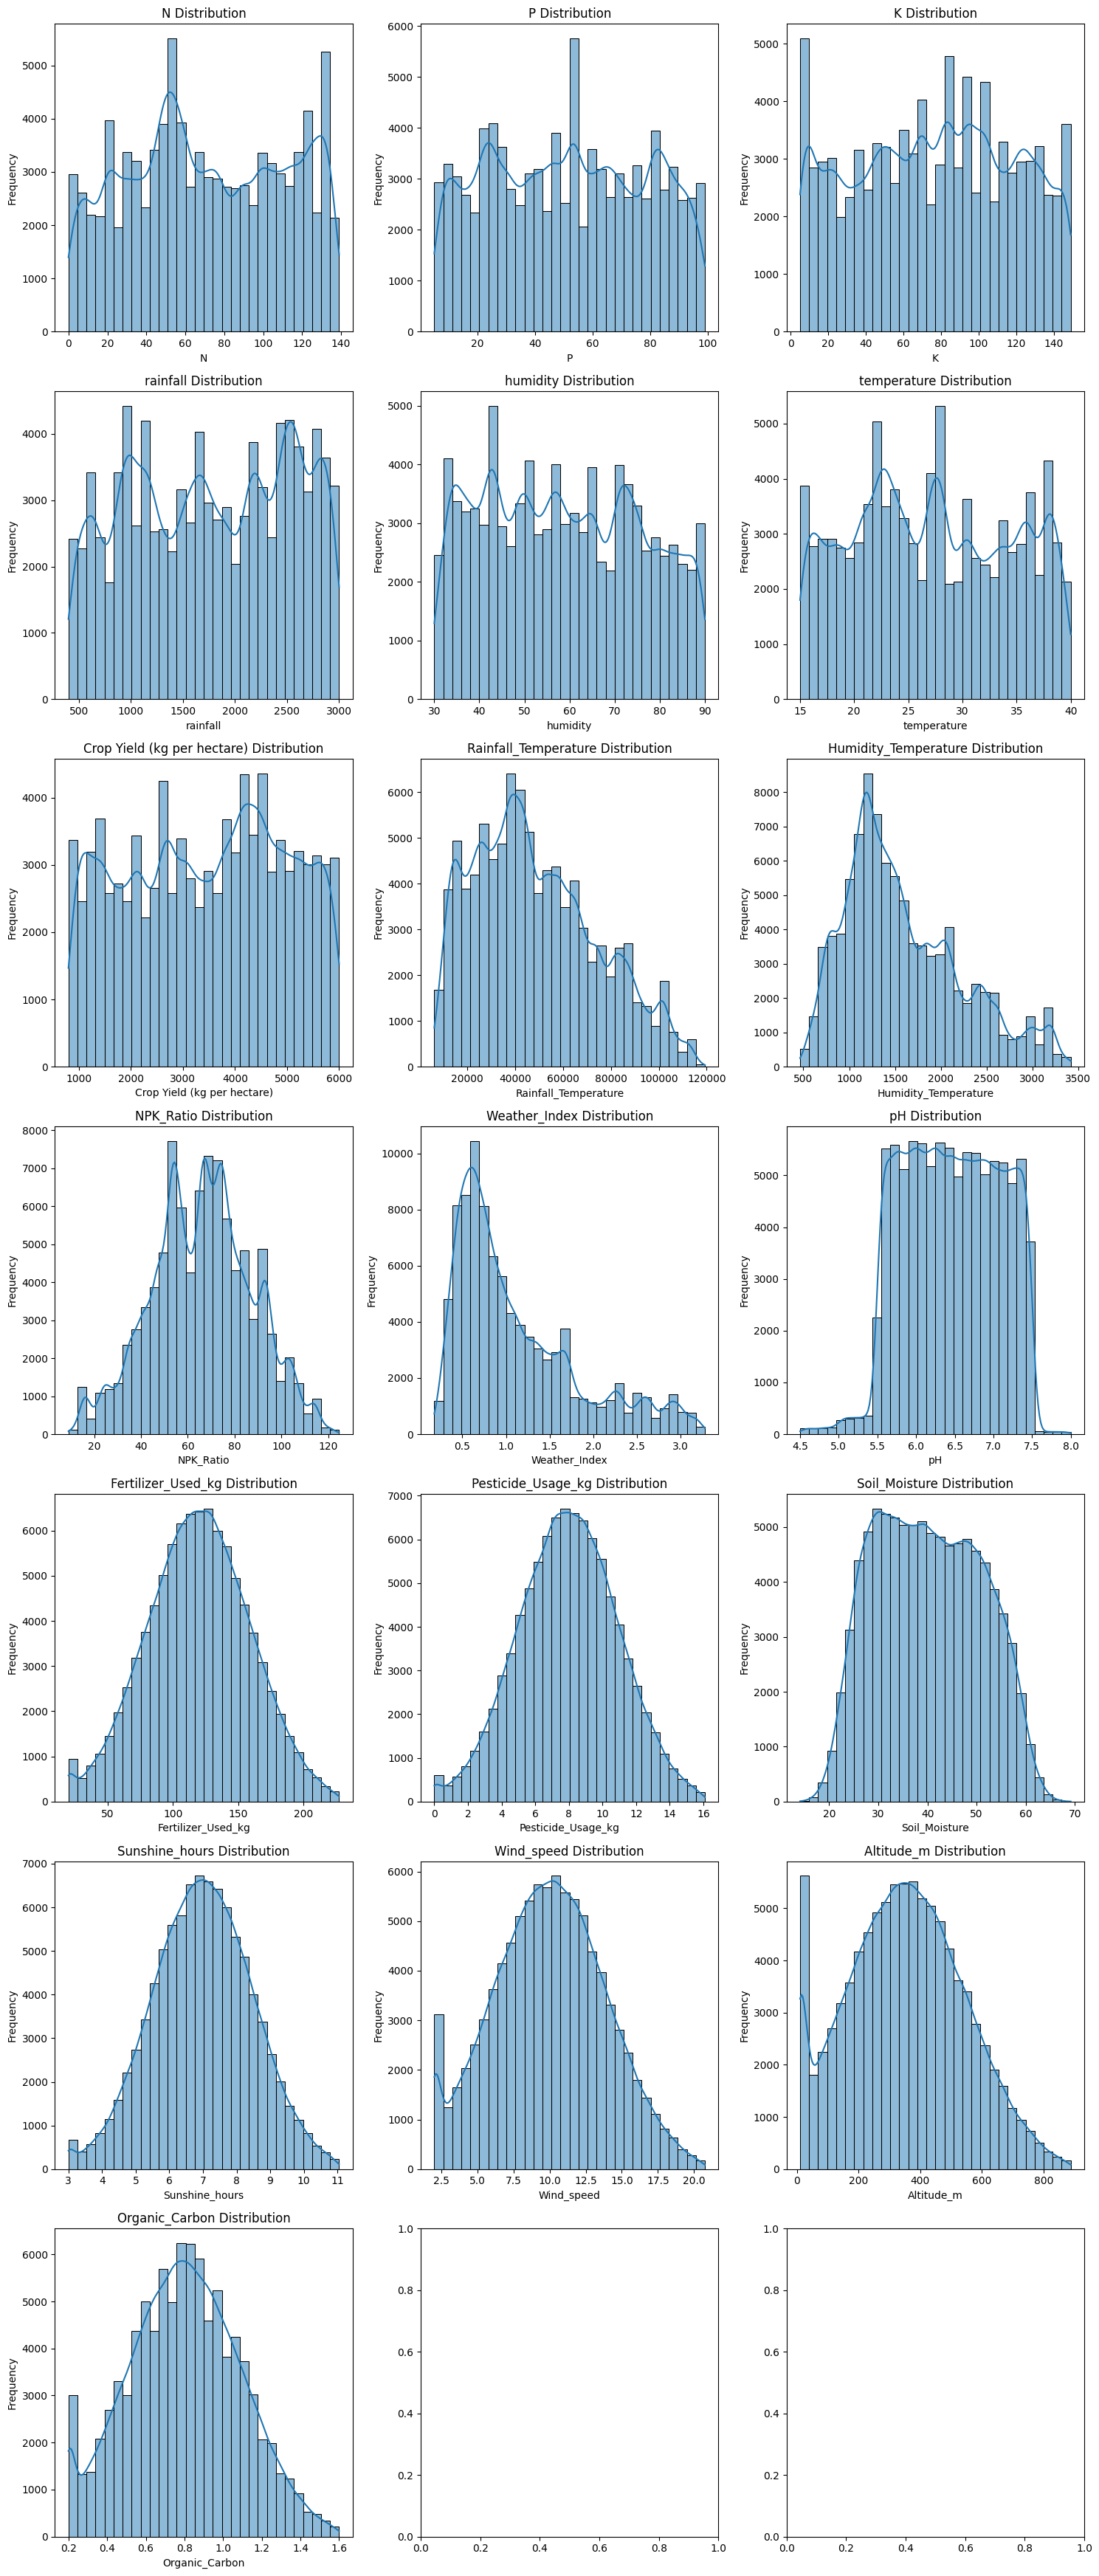

In [10]:
## Numeric Data Distrubution Module

numeric_cols = df.select_dtypes(include='number').columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], bins=30)
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Random Forest performance:
  MSE: 158746.00
  R² : 0.9284

Top 10 important features:
temperature             0.081828
K                       0.064057
humidity                0.061526
NPK_Ratio               0.060319
N                       0.060079
rainfall                0.057737
P                       0.052842
Rainfall_Temperature    0.052546
Weather_Index           0.051645
Humidity_Temperature    0.046452
dtype: float64


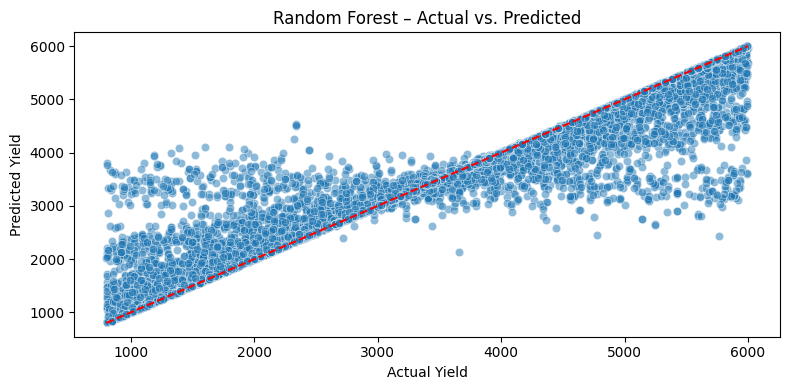

In [12]:
# -------------------------------------------------
# Random Forest baseline
# -------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define target and feature columns
target_col = 'Crop Yield (kg per hectare)'
# create a clean modeling frame that removes rows with missing target
df_model = df.dropna(subset=[target_col]).copy()
feature_cols = [col for col in df_model.columns if col != target_col]

# (reuse df_model, target_col, feature_cols from the previous block)
X = df_model[feature_cols]
y = df_model[target_col]

# one‑hot encode any categoricals
X = pd.get_dummies(X, drop_first=True)

# drop any rows with missing features (if present) and align y
X = X.dropna()
y = y.loc[X.index]

# Train‑test split (same random_state for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------
# Initialise & fit the forest
# -------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=300,          # more trees → more stable results
    max_depth=None,            # let trees grow deep (you can limit if over‑fitting)
    random_state=42,
    n_jobs=-1                  # use all cores
)
rf.fit(X_train, y_train)

# -------------------------------------------------
# Predict & evaluate
# -------------------------------------------------
y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Random Forest performance:")
print(f"  MSE: {mse:.2f}")
print(f"  R² : {r2:.4f}")

# -------------------------------------------------
# Feature importance (top 10)
# -------------------------------------------------
importances = pd.Series(rf.feature_importances_, index=X.columns)
print("\nTop 10 important features:")
print(importances.sort_values(ascending=False).head(10))

# -------------------------------------------------
# Plot actual vs. predicted
# -------------------------------------------------
plt.figure(figsize=(8,4))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Random Forest – Actual vs. Predicted')
plt.tight_layout()
plt.show()